# Quantium Task 2 - Trial vs Control Store Analysis



In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("E:/Work/Forage/Quantium/Task 2/QVI_data.csv")
df.head(5)
df['DATE']=pd.to_datetime(df['DATE'])
df['YEARMONTH']=df['DATE'].dt.strftime('%Y%m')

## Monthly Store Metrics

In [4]:
df1 = df.groupby(['STORE_NBR','YEARMONTH'],as_index=False).agg(
    total_sales=('TOT_SALES','sum'),
    unique_cust=('LYLTY_CARD_NBR','nunique'),
    unique_txn=('TXN_ID','nunique')
)

df1['trans_per_cust'] = df1['unique_txn'] / df1['unique_cust']
df1.head()


,STORE_NBR,YEARMONTH,total_sales,unique_cust,unique_txn,trans_per_cust
0,1,201807,206.9,49,52,1.061224
1,1,201808,176.1,42,43,1.023810
2,1,201809,278.8,59,62,1.050847
3,1,201810,188.1,44,45,1.022727
4,1,201811,192.6,46,47,1.021739


## Pre-Trial Period

In [5]:
pre_trial_months = [
    '201807','201808','201809',
    '201810','201811','201812',
    '201901'
]

df_pre_trial = df1[df1['YEARMONTH'].isin(pre_trial_months)]


## Keep Stores with Complete History

In [6]:
store_month_count = df_pre_trial.groupby('STORE_NBR')['YEARMONTH'].count()

valid_stores = store_month_count[store_month_count == 7].index

df_pre_trial_complete = df_pre_trial[
    df_pre_trial['STORE_NBR'].isin(valid_stores)
]


## Sales Pivot Table

In [7]:
df_pivot_sales = df_pre_trial_complete.pivot(
    index='YEARMONTH',
    columns='STORE_NBR',
    values='total_sales'
)

df_pivot_sales.head()


STORE_NBR,1,2,3,4,5,6,7,8,9,10,...,263,264,265,266,267,268,269,270,271,272
YEARMONTH,,,,,,,,,,,,,,,,,,,,,
201807,206.9,150.8,1205.70,1399.9,812.0,260.0,1024.7,381.6,289.7,892.00,...,38.7,232.6,247.8,127.3,6.2,224.00,982.0,962.80,956.6,433.10
201808,176.1,193.8,1079.75,1259.5,745.1,203.2,1119.9,383.0,327.5,878.65,...,28.0,203.3,227.1,154.5,24.9,322.65,835.1,1003.75,683.9,372.85
201809,278.8,154.4,1021.50,1198.6,896.0,207.7,1147.3,293.0,369.7,945.00,...,21.8,199.5,133.5,139.0,23.3,174.40,886.0,845.40,798.4,304.70
201810,188.1,167.8,1037.90,1346.4,798.0,292.4,1063.9,422.8,361.0,910.80,...,36.6,170.0,162.9,170.4,14.4,237.60,1078.4,816.40,790.0,430.60
201811,192.6,162.9,1008.00,1212.0,771.4,255.3,1076.5,349.2,374.4,885.00,...,15.8,184.5,282.8,144.2,40.3,225.40,967.2,965.00,886.4,376.20


## Function to Find Control Stores

In [8]:
def find_control_store(store_nbr):
    return (
        df_pivot_sales
        .corrwith(df_pivot_sales[store_nbr])
        .sort_values(ascending=False)
        .head(10)
    )

find_control_store(77)


STORE_NBR
77     1.000000
71     0.914106
233    0.903774
119    0.867664
17     0.842668
3      0.806644
41     0.783232
50     0.763866
157    0.735893
162    0.729740
dtype: float64

## Selected Trial-Control Pairs

- 77 → 233
- 86 → 155
- 88 → 40

In [15]:
trial_control_pairs = {
    77:233,
    86:155,
    88:40
}


## Sales Trend Plot

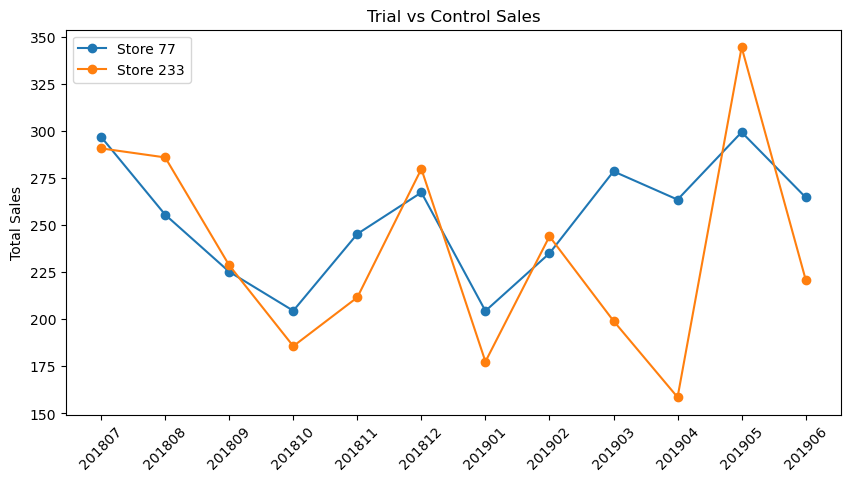

In [10]:
trial_store = 77
control_store = 233

plot_df = df1[df1['STORE_NBR'].isin([trial_store,control_store])]

plt.figure(figsize=(10,5))

for store in [trial_store,control_store]:
    temp = plot_df[plot_df['STORE_NBR']==store]
    plt.plot(temp['YEARMONTH'],
             temp['total_sales'],
             marker='o',
             label=f'Store {store}')

plt.title('Trial vs Control Sales')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend()
plt.show()


## Customer Count Trend

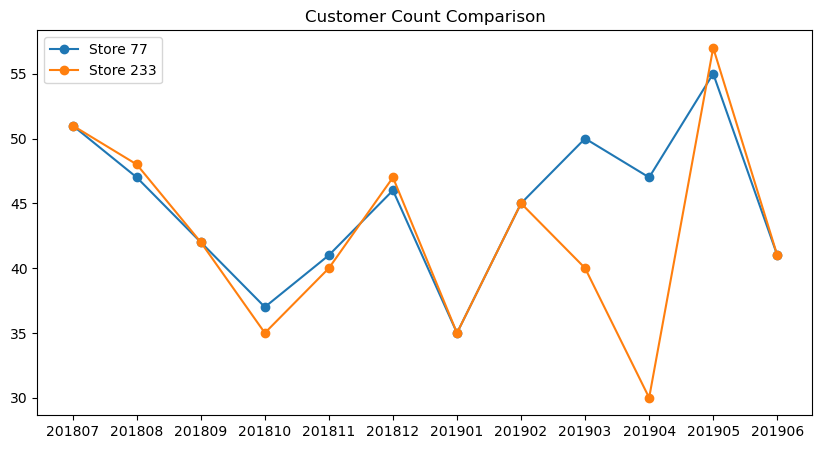

In [16]:
plt.figure(figsize=(10,5))

for store in [trial_store,control_store]:
    temp = plot_df[plot_df['STORE_NBR']==store]
    plt.plot(temp['YEARMONTH'],
             temp['unique_cust'],
             marker='o',
             label=f'Store {store}')

plt.title('Customer Count Comparison')
plt.legend()
plt.show()


## Transactions Per Customer

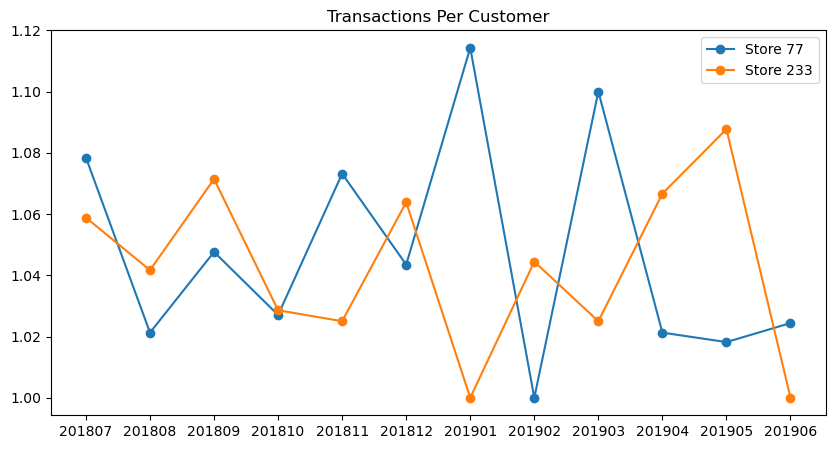

In [12]:
plt.figure(figsize=(10,5))

for store in [trial_store,control_store]:
    temp = plot_df[plot_df['STORE_NBR']==store]
    plt.plot(temp['YEARMONTH'],
             temp['trans_per_cust'],
             marker='o',
             label=f'Store {store}')

plt.title('Transactions Per Customer')
plt.legend()
plt.show()


In [13]:
trial_months = ['201902','201903','201904']

df_trial = df1[df1['YEARMONTH'].isin(trial_months)]
df_trial.head()

,STORE_NBR,YEARMONTH,total_sales,unique_cust,unique_txn,trans_per_cust
7,1,201902,225.4,52,55,1.057692
8,1,201903,192.9,45,49,1.088889
9,1,201904,192.9,42,43,1.023810
19,2,201902,139.4,29,32,1.103448
20,2,201903,192.1,43,46,1.069767


In [17]:
trial_control_pairs = {
    77:233,
    86:155,
    88:40
}

results = []

for trial, control in trial_control_pairs.items():

    trial_sales = df_trial.loc[
        df_trial['STORE_NBR']==trial,
        'total_sales'
    ].sum()

    control_sales = df_trial.loc[
        df_trial['STORE_NBR']==control,
        'total_sales'
    ].sum()

    pct_diff = (
        (trial_sales-control_sales)
        / control_sales
    ) * 100

    results.append([
        trial,
        control,
        trial_sales,
        control_sales,
        pct_diff
    ])

sales_comparison = pd.DataFrame(
    results,
    columns=[
        'Trial Store',
        'Control Store',
        'Trial Sales',
        'Control Sales',
        '% Difference'
    ]
)

sales_comparison

,Trial Store,Control Store,Trial Sales,Control Sales,% Difference
0,77,233,777.0,601.7,29.134120
1,86,155,2788.2,2540.2,9.763011
2,88,40,4286.8,3882.0,10.427615


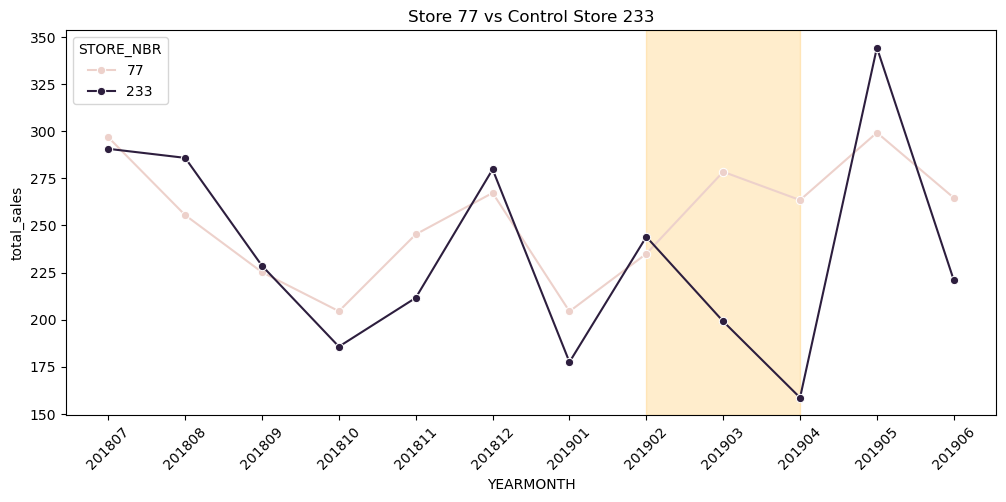

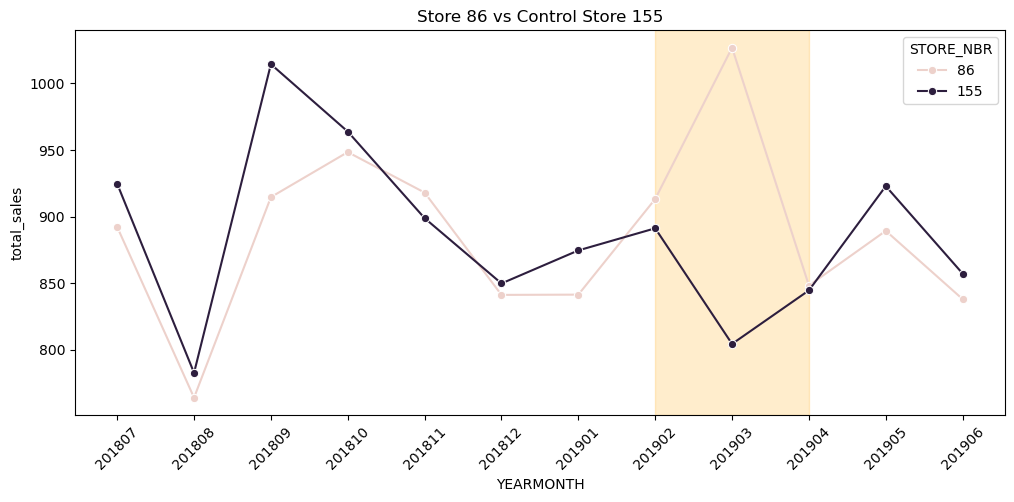

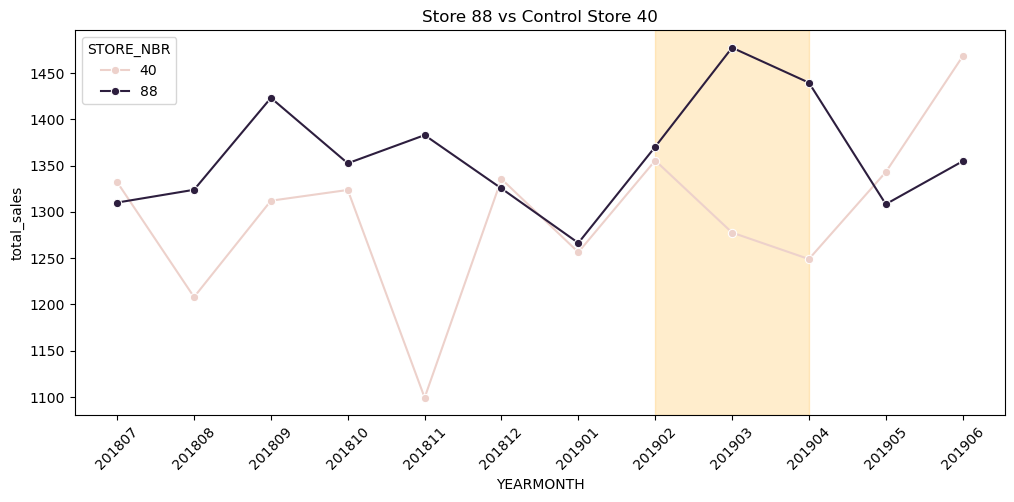

In [18]:
for trial, control in trial_control_pairs.items():

    temp = df1[
        df1['STORE_NBR'].isin([trial,control])
    ]

    plt.figure(figsize=(12,5))

    sns.lineplot(
        data=temp,
        x='YEARMONTH',
        y='total_sales',
        hue='STORE_NBR',
        marker='o'
    )

    plt.axvspan(
        '201902',
        '201904',
        alpha=0.2,
        color='orange'
    )

    plt.title(
        f'Store {trial} vs Control Store {control}'
    )

    plt.xticks(rotation=45)
    plt.show()

In [19]:
customer_results = []

for trial, control in trial_control_pairs.items():

    trial_customers = df_trial.loc[
        df_trial['STORE_NBR']==trial,
        'unique_cust'
    ].sum()

    control_customers = df_trial.loc[
        df_trial['STORE_NBR']==control,
        'unique_cust'
    ].sum()

    pct_diff = (
        (trial_customers-control_customers)
        / control_customers
    ) * 100

    customer_results.append([
        trial,
        control,
        trial_customers,
        control_customers,
        pct_diff
    ])

customer_comparison = pd.DataFrame(
    customer_results,
    columns=[
        'Trial Store',
        'Control Store',
        'Trial Customers',
        'Control Customers',
        '% Difference'
    ]
)

customer_comparison

,Trial Store,Control Store,Trial Customers,Control Customers,% Difference
0,77,233,142,115,23.478261
1,86,155,327,288,13.541667
2,88,40,386,362,6.629834


In [20]:
txn_results = []

for trial, control in trial_control_pairs.items():

    trial_txn = df_trial.loc[
        df_trial['STORE_NBR']==trial,
        'trans_per_cust'
    ].mean()

    control_txn = df_trial.loc[
        df_trial['STORE_NBR']==control,
        'trans_per_cust'
    ].mean()

    txn_results.append([
        trial,
        control,
        trial_txn,
        control_txn
    ])

txn_comparison = pd.DataFrame(
    txn_results,
    columns=[
        'Trial Store',
        'Control Store',
        'Trial Txn/Customer',
        'Control Txn/Customer'
    ]
)

txn_comparison

,Trial Store,Control Store,Trial Txn/Customer,Control Txn/Customer
0,77,233,1.040426,1.045370
1,86,155,1.235704,1.261077
2,88,40,1.253563,1.187795


## Business Conclusions

# Trial Store Assessment

Control stores were selected based on similarity in pre-trial sales performance, customer counts and transactions per customer. The selected control stores were Store 233 for Trial Store 77, Store 155 for Trial Store 86 and Store 40 for Trial Store 88.

Store 77 delivered the strongest sales uplift during the trial period, outperforming its control store by 29.1%. The improvement was largely driven by a 23.5% increase in customer numbers while purchasing frequency remained stable.

Store 86 outperformed its control store by 9.8%. Customer counts increased by 13.5%, indicating that the trial was effective in attracting additional shoppers despite a small decline in transactions per customer.

Store 88 achieved a 10.4% sales uplift relative to its control store. Growth was driven by both higher customer numbers and increased transactions per customer, indicating strong customer engagement during the trial.

Overall, all three trial stores outperformed their respective control stores during the trial period. The strongest performance was observed in Store 77, while Store 88 demonstrated the most balanced improvement across both customer acquisition and purchasing behaviour.

Recommendation: The trial should be considered successful and the initiative should be evaluated for rollout to similar stores across the network.

